<a href="https://colab.research.google.com/github/KoreJosh/Customer-Segmentation-Cluster/blob/main/Customer_Segmentation_Custer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Data/Mall_Customers.csv')

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
# Select numerical features and compute correlations
numerical_df = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
corr_matrix = numerical_df.corr()

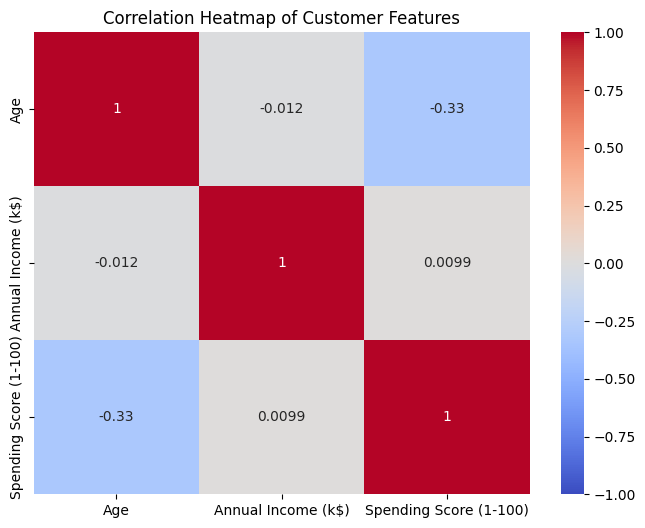

In [ ]:
#checking if there is a correlation in our numerical features
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,  # Show correlation values
    cmap='coolwarm',  # Red (positive) vs. Blue (negative)
    vmin=-1, vmax=1  # Fix scale from -1 to 1
)
plt.title("Correlation Heatmap of Customer Features")
plt.show()

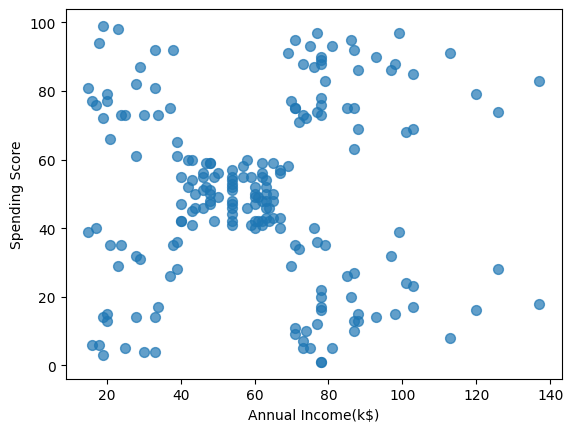

In [ ]:
points = df.iloc[:,3:].values
X= points[:,0]
y = points[:,1]

plt.scatter(X,y, s=50, alpha=.7)
plt.xlabel('Annual Income(k$)')
plt.ylabel('Spending Score')
plt.show()

In [ ]:
# Using Elbow method, determine the optimum number of clusters

Text(0, 0.5, 'Inertia')

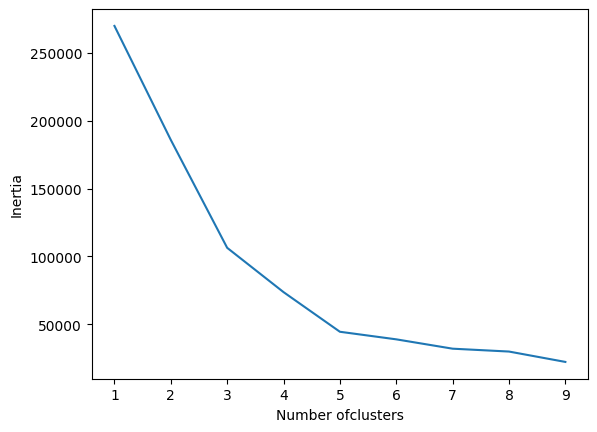

In [ ]:
inertias = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters = i, random_state = 0)
    kmeans.fit(points)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,10), inertias)
plt.xlabel('Number ofclusters')
plt.ylabel('Inertia')

In [ ]:
'Looks as if the optimum number of clusters is 5. Therefore, segment the customers using five clusters.'

'Looks as if the optimum number of clusters is 5. Therefore, segment the customers using five clusters.'

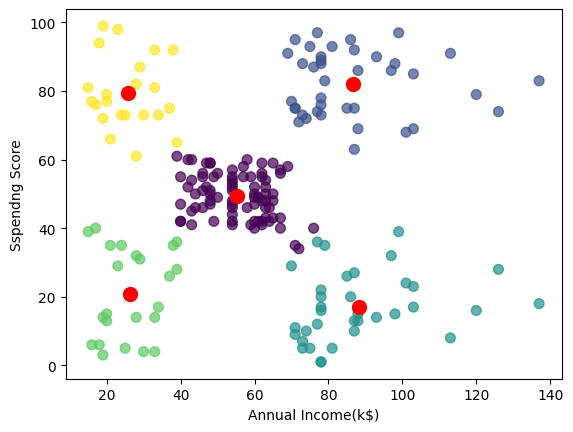

In [ ]:
kmeans = KMeans(n_clusters = 5, random_state =0)
kmeans.fit(points)
predicted_cluster_indexes = kmeans.predict(points)

plt.scatter(X,y, c= predicted_cluster_indexes, s=50, alpha=.7, cmap='viridis')
plt.xlabel('Annual Income(k$)')
plt.ylabel('Sspendng Score')

centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], c='red', s=100)

In [ ]:
dF =df.copy()
dF['Cluster'] = kmeans.predict(points)
dF.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,3
1,2,Male,21,15,81,4
2,3,Female,20,16,6,3
3,4,Female,23,16,77,4
4,5,Female,31,17,40,3


In [ ]:
import numpy as np

# Get the cluster index for a customer with a high income and low spending score
cluster = kmeans.predict(np.array([[120, 20]]))[0]

# Filter the DataFrame to include only customers in that cluster
clustered_df = dF[dF['Cluster'] == cluster]

# Show the customer IDs
clustered_df['CustomerID'].values

array([125, 129, 131, 135, 137, 139, 141, 145, 147, 149, 151, 153, 155,
       157, 159, 161, 163, 165, 167, 169, 171, 173, 175, 177, 179, 181,
       183, 185, 187, 189, 191, 193, 195, 197, 199])

These might be great customers to target with a promotion to entice them to buy more of your product. If you were going to roll out a loyalty program instead to reward customers who already buy your product, which cluster (or clusters) would you target?

## Using Age,Income, Spending Score

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Text(0, 0.5, 'Inertia')

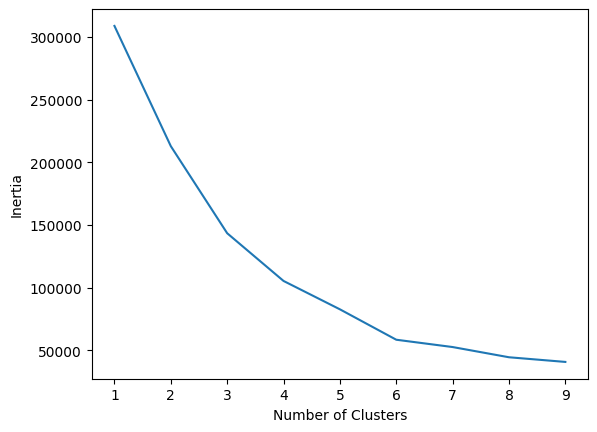

In [ ]:
inertias = []
points = df.iloc[:, 2:5].values

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(points)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, 10), inertias)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

accomodating more indicators to determine the luster of cutomers,Looks as if the optimum number of clusters is 6. Therefore, segment the customers using five clusters.'

In [ ]:
KM = KMeans(n_clusters = 6, random_state =0)
KM.fit(points)
dF1= df.copy()
dF1['Cluster'] = KM.predict(points)
dF1.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,5
2,3,Female,20,16,6,2
3,4,Female,23,16,77,5
4,5,Female,31,17,40,2


In [ ]:
dF1.Cluster.value_counts()

,count
Cluster,
0,44
1,39
4,38
3,34
5,23
2,22


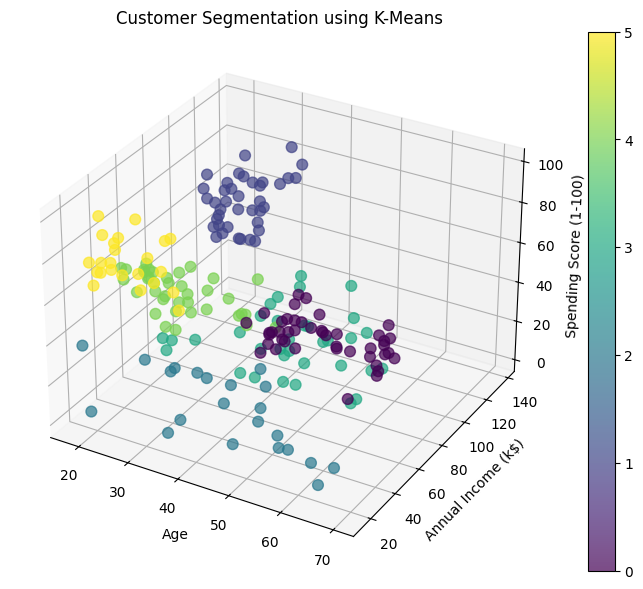

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['Age'],
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=dF1['Cluster'],
    cmap='viridis',
    alpha =.7,
    s = 60
)


ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
plt.title('Customer Segmentation using K-Means')
plt.colorbar(scatter)
plt.show()

In [ ]:
#creating a 3d scatter plot to better view  the clusters in all direction.
centers = KM.cluster_centers_

# Create Plotly 3D scatter plot
fig = go.Figure()

# Add data points (colored by cluster)
for cluster in sorted(dF1['Cluster'].unique()):
    cluster_df = dF1[dF1['Cluster'] == cluster]
    fig.add_trace(go.Scatter3d(
        x=cluster_df['Age'],
        y=cluster_df['Annual Income (k$)'],
        z=cluster_df['Spending Score (1-100)'],
        mode='markers',
        marker=dict(
            size=8,
            opacity=0.8,
            color=cluster,  # Use cluster number for color
            colorscale='Viridis'
        ),
        name=f'Cluster {cluster}'
    ))

# Add cluster centers
fig.add_trace(go.Scatter3d(
    x=centers[:, 0],
    y=centers[:, 1],
    z=centers[:, 2],
    mode='markers',
    marker=dict(
        size=12,
        color='red',
        symbol='x'
    ),
    name='Cluster Centers'
))

# Update layout
fig.update_layout(
    title='Customer Segmentation with K-Means (Interactive 3D)',
    scene=dict(
        xaxis_title='Age',
        yaxis_title='Annual Income (k$)',
        zaxis_title='Spending Score (1-100)'
    ),
    width=1000,
    height=800,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

In [ ]:
# Create an empty DataFrame to store results
result = pd.DataFrame(columns=['Cluster', 'Average Age', 'Average Income', 'Average Spending Index'])

for i, center in enumerate(KM.cluster_centers_):
    age = center[0]    # 0 = Age (first column in cluster centers)
    income = center[1] # 1 = Income (second column)
    spend = center[2]  # 2 = Spending Score (third column)

    # Assign to the result DataFrame (note: use 'result', not 'results')
    result.loc[i] = [i, age, income, spend]

result.head(7)

,Cluster,Average Age,Average Income,Average Spending Index
0,0.0,56.340909,53.704545,49.386364
1,1.0,32.692308,86.538462,82.128205
2,2.0,44.318182,25.772727,20.272727
3,3.0,41.647059,88.735294,16.764706
4,4.0,27.315789,57.500000,48.447368
5,5.0,25.521739,26.304348,78.565217


## Using All Attributes

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['gender'] = encoder.fit_transform(df['Gender'])
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),gender
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'gender'],
      dtype='object')

In [ ]:
df1 = df[['gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)']]
df1.head()

,gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


Text(0, 0.5, 'Inertia')

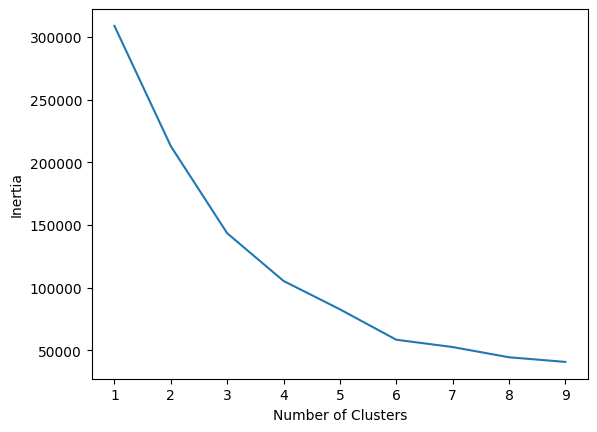

In [ ]:
inertias = []
points = df1.iloc[:, :5].values

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(points)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, 10), inertias)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

In [ ]:
kMeans = KMeans(n_clusters=6, random_state=0)
kMeans.fit(points)

df1['Cluster'] = kMeans.predict(points)
df1.head()

<ipython-input-29-2cecbfae379d>:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,2
1,1,21,15,81,5
2,0,20,16,6,2
3,0,23,16,77,5
4,0,31,17,40,2


In [ ]:
df1.Cluster.value_counts()

,count
Cluster,
0,44
1,39
4,38
3,34
5,23
2,22


In [ ]:
results = pd.DataFrame(columns = ['Cluster', 'Average Age', 'Average Income', 'Average Spending Index', 'Number of Females', 'Number of Males'])

for i, center in enumerate(kMeans.cluster_centers_):
    age = center[1]    # Average age for current cluster
    income = center[2] # Average income for current cluster
    spend = center[3]  # Average spending score for current cluster

    gdf = df1[df1['Cluster'] == i]
    females = gdf[gdf['gender'] == 0].shape[0]
    males = gdf[gdf['gender'] == 1].shape[0]

    results.loc[i] = ([i, age, income, spend, females, males])

results.head(7)

,Cluster,Average Age,Average Income,Average Spending Index,Number of Females,Number of Males
0,0.0,56.340909,53.704545,49.386364,25.0,19.0
1,1.0,32.692308,86.538462,82.128205,21.0,18.0
2,2.0,44.318182,25.772727,20.272727,13.0,9.0
3,3.0,41.647059,88.735294,16.764706,15.0,19.0
4,4.0,27.315789,57.500000,48.447368,24.0,14.0
5,5.0,25.521739,26.304348,78.565217,14.0,9.0


Including the gender gave no more difference in the customer cluster which aligns with using just age, income and spending score to group our customers.
From the above Customers with average age of 41 and above had low spending score, and their average income isn't doing justice to their spending score has they also have high earning capacit, it can be deduce that the store sells product for middle_age individauls.

# Hierarchical Clustering

In [ ]:
X = df.iloc[:,[3,4]].values

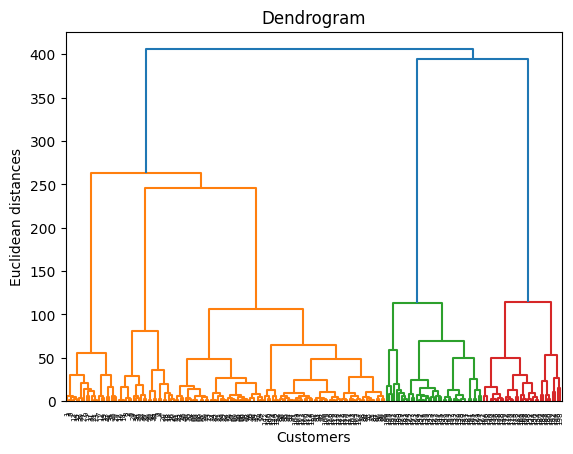

In [ ]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 5,  linkage = 'ward')
y_hc = hc.fit_predict(X)

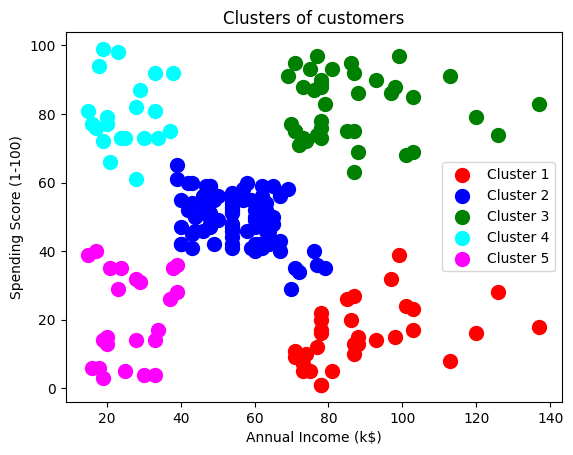

In [ ]:
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## Using Age,Income, Spending Score

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),gender
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


In [ ]:
import plotly.figure_factory as ff
import plotly.graph_objects as go
from scipy.cluster.hierarchy import linkage, fcluster

# Select and normalize features
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)


In [ ]:
# ===== HIERARCHICAL CLUSTERING =====
# Compute linkage matrix
Z = linkage(X_normalized, method='ward', metric='euclidean')

# Choose number of clusters (e.g., 3) and get labels
max_clusters = 6
df['Cluster'] = fcluster(Z, max_clusters, criterion='maxclust')

In [ ]:
# ===== 3D INTERACTIVE VISUALIZATION =====
fig = go.Figure()

# Add data points (colored by cluster)
for cluster in sorted(df['Cluster'].unique()):
    cluster_df = df[df['Cluster'] == cluster]
    fig.add_trace(go.Scatter3d(
        x=cluster_df['Age'],
        y=cluster_df['Annual Income (k$)'],
        z=cluster_df['Spending Score (1-100)'],
        mode='markers',
        marker=dict(
            size=10,
            opacity=0.8,
            color=cluster,  # Color by cluster
            colorscale='Viridis'
        ),
        name=f'Cluster {cluster}',
        hovertext=cluster_df['CustomerID']
    ))

# Add dendrogram (2D) in a subplot
dendro = ff.create_dendrogram(Z, orientation='bottom')
dendro.update_layout(width=800, height=400)

# Combine plots
fig.update_layout(
    title='Hierarchical Clustering: Customer Segmentation',
    scene=dict(
        xaxis_title='Age',
        yaxis_title='Annual Income (k$)',
        zaxis_title='Spending Score (1-100)'
    ),
    width=1000,
    height=800
)

# Show interactive plot
fig.show()

# Optionally show dendrogram separately
dendro.show()